# Análisis Exploratorio de Datos (EDA) — Clasificación del método de descubrimiento de exoplanetas

**Objetivo:** profundizar la comprensión del dataset limpio generado en el ETL, validar hipótesis sobre cómo las variables físicas, orbitales y estelares varían entre métodos de descubrimiento, y obtener insumos para la etapa de modelado.

**Variable objetivo (target):** `discoverymethod` (multiclase).

**Insumo:** dataset limpio producido por `02_etl_parte2.ipynb` y guardado en `Data/processed/NASA_Exoplanet_Clean_DiscoveryMethod.csv`.

**Salida esperada:** validación de las hipótesis planteadas, identificación de las variables más discriminantes y una serie de patrones para guiar la selección de modelos en el Sprint 3.

## Hipótesis planteadas

Cada método de detección de exoplanetas tiene **sesgos físicos** conocidos: detecta más fácilmente cierto tipo de planetas. Esto sugiere que las variables del dataset deberían distribuirse de manera **diferente** según el método con el que se descubrió cada planeta. A partir de esto formulamos:

### H1 — Sesgo de radio planetario
El método **Transit** detecta planetas observando la caída de brillo cuando el planeta cruza frente a su estrella. La señal es más fuerte cuanto mayor sea el radio planetario relativo al estelar. Por lo tanto, esperamos que la distribución de `pl_rade` (radio planetario en radios terrestres) sea **significativamente distinta** entre métodos, con Transit favoreciendo planetas de radio intermedio-grande respecto a, por ejemplo, Radial Velocity.

### H2 — Sesgo de masa y período orbital
El método **Radial Velocity** mide el bamboleo de la estrella causado por la gravedad del planeta. La señal es más fuerte cuanto **mayor sea la masa del planeta** y **menor el período orbital**. Por lo tanto, esperamos que en Radial Velocity la masa planetaria (`pl_bmasse`) tienda a ser **mayor** y el período orbital (`pl_orbper`) **distinto** que en otros métodos.

### H3 — Sesgo de distancia al sistema
Los métodos **Microlensing** y **Imaging** son sensibles a sistemas a mayor distancia (en parsecs) que Transit o Radial Velocity, que dependen de medir variaciones de brillo o velocidad con buena relación señal-ruido y por tanto favorecen estrellas cercanas y brillantes. Esperamos que la mediana de `sy_dist` sea **significativamente mayor** en Microlensing/Imaging que en Transit/Radial Velocity.

### Hipótesis adicional (H4) — Relación masa-radio
Independientemente del método, **existe una relación monótona positiva** entre el radio (`pl_rade`) y la masa (`pl_bmasse`) de los planetas (planetas más grandes tienden a ser más masivos), pero esa relación no es lineal porque a partir de cierto tamaño el radio se estabiliza (planetas gigantes con composiciones distintas).

---

**Cómo se valida cada hipótesis:**
- **Visualmente:** boxplots y scatterplots agrupados por `discoverymethod`.
- **Estadísticamente:** test de Kruskal-Wallis (no paramétrico, no asume normalidad) para comparar distribuciones entre métodos; correlación de Spearman para H4.

## 1. Importación de librerías y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

INPUT_PATH = "../Data/processed/NASA_Exoplanet_Clean_DiscoveryMethod.csv"
df = pd.read_csv(INPUT_PATH)

print(f"Shape del dataset: {df.shape}")
print(f"Columnas: {df.shape[1]}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
df.head()

Shape del dataset: (5757, 42)
Columnas: 42
Nulos totales: 0


,sy_snum,sy_pnum,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,ra,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag,pl_bmasse_missing,pl_rade_missing,pl_orbper_missing,pl_orbsmax_missing,pl_orbeccen_missing,st_teff_missing,st_rad_missing,st_mass_missing,st_met_missing,st_logg_missing,sy_dist_missing,ra_missing,dec_missing,pl_bmasse_log,pl_rade_log,pl_orbper_log,pl_orbsmax_log,pl_eqt_log,sy_dist_log,st_mass_log,st_rad_log,st_teff_log
0,2,1,Radial Velocity,323.2100,1.1780,2.4000,4914.8985,0.2380,903.0000,4874.0000,13.7600,2.0900,-0.2600,2.4500,185.1788,17.7933,93.1846,4.7231,2.2820,4.4404,0,1,0,0,0,0,0,0,0,0,0,0,0,8.5002,1.2238,5.7814,0.7784,6.8068,4.5453,1.1282,2.6919,8.4919
1,1,1,Radial Velocity,516.2200,1.5300,2.4000,4684.8142,0.0800,903.0000,4213.0000,29.7900,2.7800,-0.0200,1.9300,229.2746,71.8239,125.3210,5.0130,1.9390,4.5622,0,1,0,0,0,0,0,0,0,0,0,0,0,8.4523,1.2238,6.2485,0.9282,6.8068,4.8388,1.3297,3.4272,8.3462
2,1,1,Radial Velocity,186.7600,0.7750,2.4000,1131.1513,0.0000,903.0000,4888.0000,11.5500,1.7800,-0.2100,2.5500,352.8241,39.2358,75.4392,5.2313,2.3310,4.9178,0,1,0,0,0,0,0,0,0,0,0,0,0,7.0319,1.2238,5.2352,0.5738,6.8068,4.3365,1.0225,2.5297,8.4947
3,1,2,Radial Velocity,1765.0389,2.7740,2.4000,2559.4722,0.3730,903.0000,5551.0000,0.9500,0.9100,0.0200,4.4600,242.6021,43.8164,17.9323,6.6193,4.7140,6.3830,0,1,0,0,0,1,1,0,1,1,0,0,0,7.8479,1.2238,7.4765,1.3281,6.8068,2.9409,0.6471,0.6678,8.6219
4,3,1,Radial Velocity,798.5000,1.6600,2.4000,565.7374,0.6800,903.0000,5750.0000,1.1300,1.0800,0.0600,4.3600,295.4656,50.5168,21.1397,6.2150,4.6510,6.0643,0,1,0,0,0,0,0,0,0,0,0,0,0,6.3399,1.2238,6.6840,0.9783,6.8068,3.0974,0.7324,0.7561,8.6571


## 2. Panorámica del target

Antes de cruzar variables conviene refrescar **cómo se distribuye** la variable objetivo. Esto nos recuerda que el dataset está fuertemente desbalanceado: Transit domina ampliamente sobre los demás métodos. Es un dato crítico a tener en cuenta para la etapa de modelado (será necesario usar métricas robustas al desbalance, como F1 macro, o aplicar técnicas de balanceo).

Distribución del target:
                 cantidad  porcentaje
discoverymethod                      
Transit              4304     74.7600
Radial Velocity      1080     18.7600
Microlensing          230      4.0000
Other                 143      2.4800


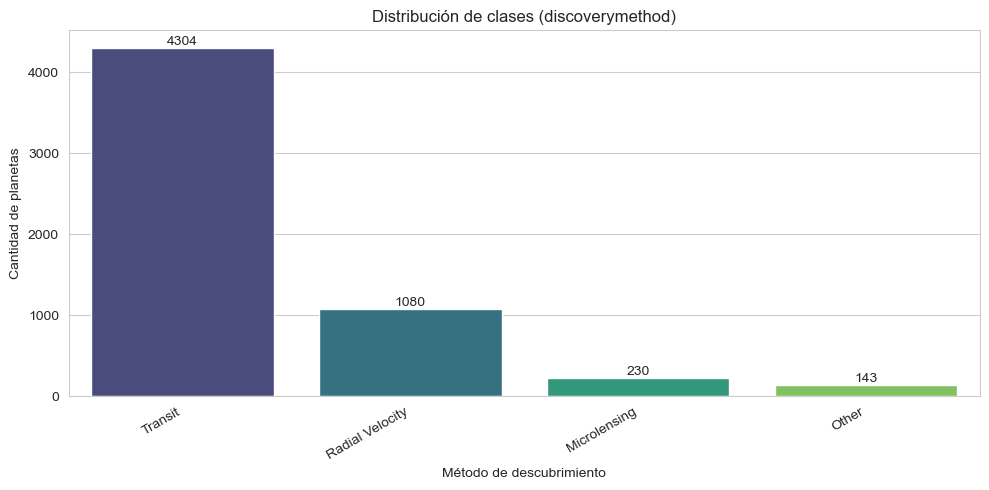

In [2]:
target_counts = df["discoverymethod"].value_counts()
target_pct = (target_counts / target_counts.sum() * 100).round(2)

resumen_target = pd.DataFrame({"cantidad": target_counts, "porcentaje": target_pct})
print("Distribución del target:")
print(resumen_target)

plt.figure(figsize=(10, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette="viridis", legend=False)
plt.title("Distribución de clases (discoverymethod)")
plt.ylabel("Cantidad de planetas")
plt.xlabel("Método de descubrimiento")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(target_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Resumen estadístico por clase

Calculamos la **mediana** de las variables físicas, orbitales y estelares clave separadas por método de descubrimiento. Usamos mediana en lugar de media porque las variables astronómicas son fuertemente asimétricas (hay órdenes de magnitud entre planetas pequeños rocosos y gigantes gaseosos) y la mediana es más robusta a esa asimetría.

**Nota importante:** las variables `pl_bmasse`, `pl_orbeccen` y otras fueron imputadas con mediana global durante el ETL. Para análisis bivariados que comparen distribuciones reales, **filtraremos los valores imputados** usando los indicadores `_missing` generados en el ETL. Esto evita que la mediana imputada contamine las comparaciones entre grupos.

In [3]:
key_vars = ["pl_rade", "pl_bmasse", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
            "sy_dist", "st_teff", "st_mass", "st_met"]
key_vars = [c for c in key_vars if c in df.columns]

medianas_por_clase = df.groupby("discoverymethod")[key_vars].median().T
print("Mediana de variables clave por método de descubrimiento:")
medianas_por_clase.round(3)

Mediana de variables clave por método de descubrimiento:


discoverymethod,Microlensing,Other,Radial Velocity,Transit
pl_rade,2.4000,2.4000,2.4000,2.3900
pl_bmasse,180.5810,2383.6000,340.6090,187.5200
pl_orbper,11.2670,11.2670,352.4250,8.3190
pl_orbsmax,2.1750,10.0180,0.9150,0.1160
pl_orbeccen,0.0860,0.0860,0.1500,0.0860
sy_dist,5985.0000,159.5370,44.5420,508.0710
st_teff,5551.0000,5551.0000,5551.0000,5580.0000
st_mass,0.4300,0.9500,1.0200,0.9500
st_met,0.0200,0.0200,0.0200,0.0200


## 4. Matriz de correlación

La matriz de correlación nos sirve para tres cosas:
1. Detectar **redundancia** entre features (variables muy correlacionadas aportan información parecida y pueden afectar a algunos modelos).
2. Detectar **relaciones físicas** esperadas (por ejemplo, masa y radio estelares deberían correlacionar positivamente; magnitudes ópticas y distancia, también).
3. Detectar variables **potencialmente predictivas** del target (variables con relación monotónica fuerte con la clase).

Usamos el coeficiente de **Spearman** porque mide relaciones monótonas (no necesariamente lineales), lo cual encaja mejor con datos astronómicos que viven en muchas escalas distintas.

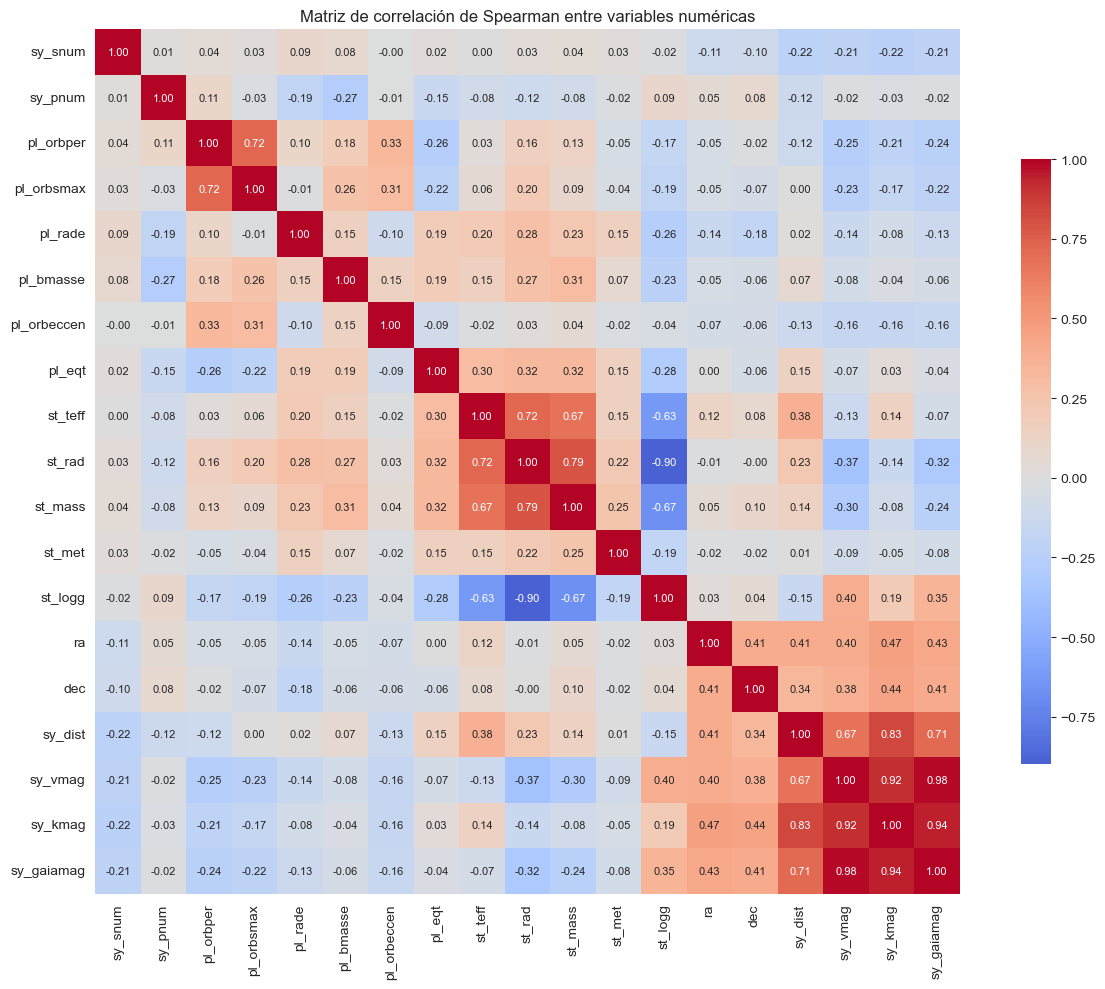

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
base_numeric = [c for c in numeric_cols if not c.endswith("_missing") and not c.endswith("_log")]

corr_matrix = df[base_numeric].corr(method="spearman")

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
plt.title("Matriz de correlación de Spearman entre variables numéricas")
plt.tight_layout()
plt.show()

### Correlación de cada variable con el target

Codificamos `discoverymethod` numéricamente para poder calcular una **correlación de referencia** entre cada variable y la clase. Es solo una aproximación (la correlación lineal/monotónica entre una variable continua y una clase categórica tiene limitaciones), pero nos da una **primera idea** de cuáles variables podrían tener más poder predictivo.

Correlación de Spearman entre cada variable y el target (codificado):
pl_orbsmax    -0.5520
sy_kmag        0.5390
sy_gaiamag     0.5330
sy_vmag        0.5200
pl_orbper     -0.4260
dec            0.3860
sy_dist        0.3270
ra             0.3020
pl_orbeccen   -0.2880
pl_bmasse     -0.1830
st_logg        0.1400
sy_snum       -0.1130
st_teff        0.1080
st_rad        -0.1050
st_mass        0.0510
pl_eqt         0.0330
sy_pnum        0.0300
st_met        -0.0280
pl_rade       -0.0200
Name: target_code, dtype: float64


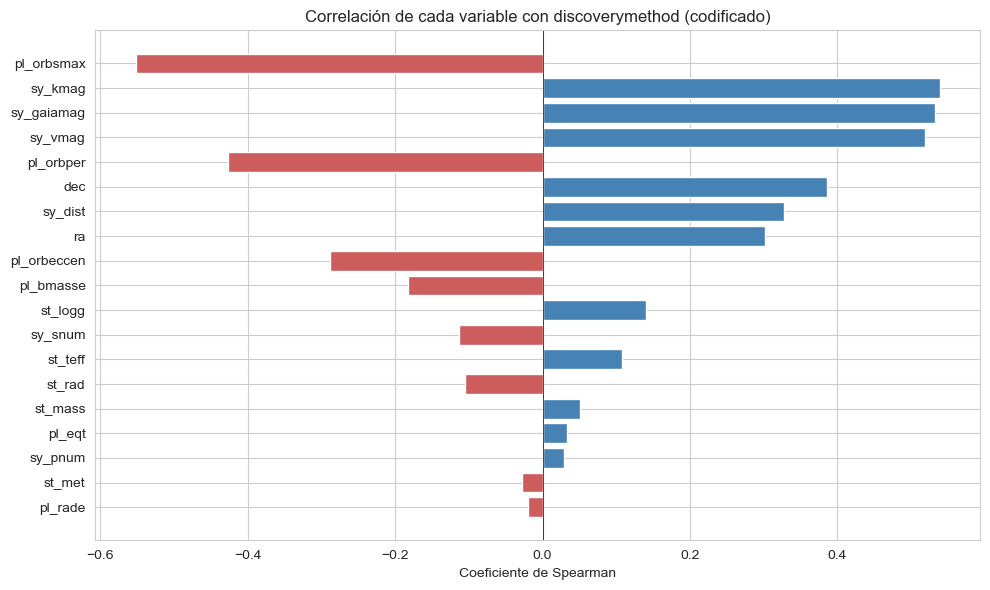

In [5]:
df["target_code"] = pd.Categorical(df["discoverymethod"]).codes

corr_target = df[base_numeric + ["target_code"]].corr(method="spearman")["target_code"].drop("target_code")
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

print("Correlación de Spearman entre cada variable y el target (codificado):")
print(corr_target.round(3))

plt.figure(figsize=(10, 6))
colors = ["steelblue" if v > 0 else "indianred" for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Correlación de cada variable con discoverymethod (codificado)")
plt.xlabel("Coeficiente de Spearman")
plt.tight_layout()
plt.show()

df = df.drop(columns=["target_code"])

## 5. Validación H1 — Sesgo de radio planetario

Comparamos la distribución de `pl_rade` (en escala logarítmica, por la fuerte asimetría) entre los distintos métodos de descubrimiento. Filtramos los valores que fueron imputados durante el ETL para no sesgar la comparación con la mediana global.

Planetas con radio medido (no imputado): 4342 de 5757


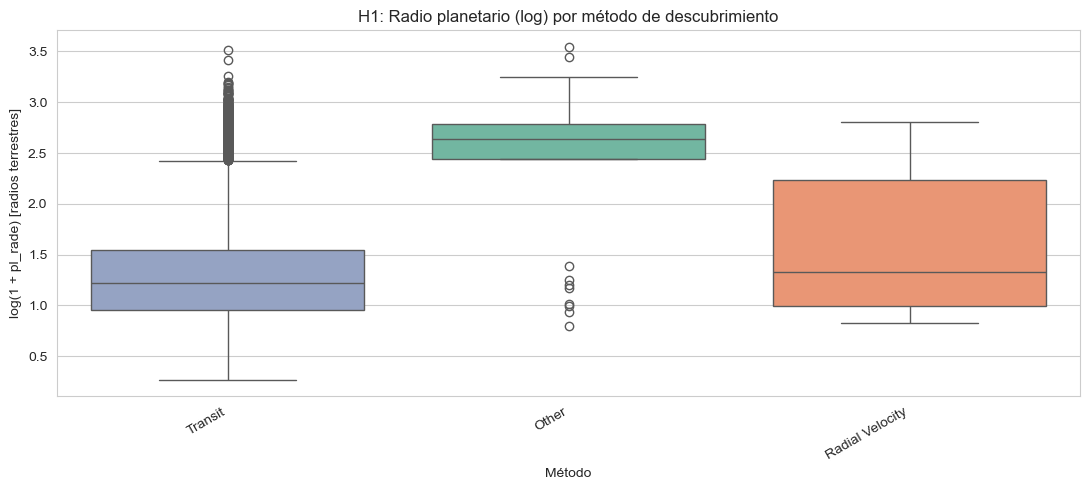


Mediana de pl_rade (radios terrestres) por método:
discoverymethod
Other             13.0000
Radial Velocity    2.7730
Transit            2.3900
Name: pl_rade, dtype: float64

Test de Kruskal-Wallis: H = 38.66, p-value = 4.0318e-09
Conclusión: Rechazamos H0 (al menos un método tiene distribución distinta) (α = 0.05)


In [6]:
df_rade_real = df[df["pl_rade_missing"] == 0].copy()
print(f"Planetas con radio medido (no imputado): {len(df_rade_real)} de {len(df)}")

order = df_rade_real["discoverymethod"].value_counts().index

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_rade_real, x="discoverymethod", y="pl_rade_log",
            order=order, hue="discoverymethod", palette="Set2", legend=False)
plt.title("H1: Radio planetario (log) por método de descubrimiento")
plt.ylabel("log(1 + pl_rade) [radios terrestres]")
plt.xlabel("Método")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nMediana de pl_rade (radios terrestres) por método:")
print(df_rade_real.groupby("discoverymethod")["pl_rade"].median().sort_values(ascending=False).round(3))

grupos = [g["pl_rade_log"].dropna().values for _, g in df_rade_real.groupby("discoverymethod") if len(g) > 5]
stat, p_value = stats.kruskal(*grupos)
print(f"\nTest de Kruskal-Wallis: H = {stat:.2f}, p-value = {p_value:.4e}")
print("Conclusión:", "Rechazamos H0 (al menos un método tiene distribución distinta)" if p_value < 0.05 
      else "No rechazamos H0", "(α = 0.05)")

**Interpretación H1:** si el p-value es < 0.05 (esperado), rechazamos la hipótesis nula de igualdad de distribuciones. Es decir, **el radio planetario varía significativamente entre métodos de descubrimiento**, lo que confirma la hipótesis del sesgo de detección. Esto convierte a `pl_rade` (o su versión logarítmica) en un **buen candidato** como feature predictiva para el modelo.

## 6. Validación H2 — Sesgo de masa y período orbital

Comparamos masa planetaria (`pl_bmasse`) y período orbital (`pl_orbper`) entre métodos. Esperamos que Radial Velocity favorezca planetas más masivos. Filtramos los valores imputados.

Planetas con masa medida: 2706
Planetas con período orbital medido: 5472


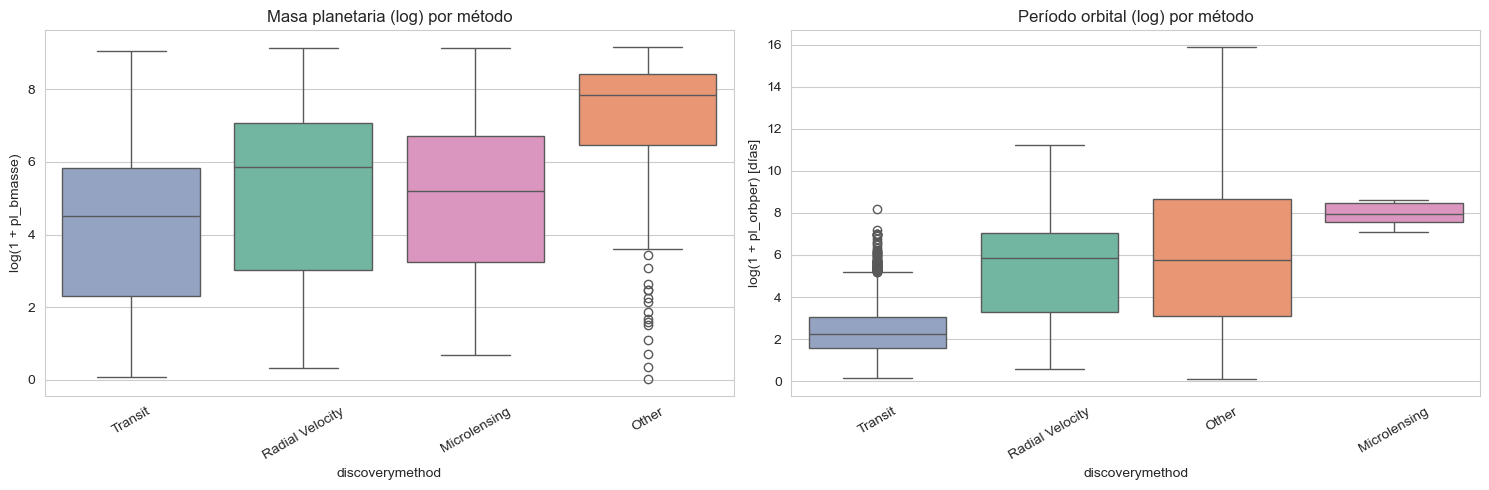


Mediana de pl_bmasse (masas terrestres) por método:
discoverymethod
Other             2542.6300
Radial Velocity    346.4300
Microlensing       180.5800
Transit             88.8800
Name: pl_bmasse, dtype: float64

Kruskal-Wallis para masa: H = 278.93, p-value = 3.6148e-60
Kruskal-Wallis para período: H = 1358.33, p-value = 3.2401e-294


In [7]:
df_mass_real = df[df["pl_bmasse_missing"] == 0].copy()
df_orbper_real = df[df["pl_orbper_missing"] == 0].copy()

print(f"Planetas con masa medida: {len(df_mass_real)}")
print(f"Planetas con período orbital medido: {len(df_orbper_real)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_mass = df_mass_real["discoverymethod"].value_counts().index
sns.boxplot(data=df_mass_real, x="discoverymethod", y="pl_bmasse_log", order=order_mass,
            hue="discoverymethod", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Masa planetaria (log) por método")
axes[0].set_ylabel("log(1 + pl_bmasse)")
axes[0].tick_params(axis="x", rotation=30)

order_orbper = df_orbper_real["discoverymethod"].value_counts().index
sns.boxplot(data=df_orbper_real, x="discoverymethod", y="pl_orbper_log", order=order_orbper,
            hue="discoverymethod", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Período orbital (log) por método")
axes[1].set_ylabel("log(1 + pl_orbper) [días]")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nMediana de pl_bmasse (masas terrestres) por método:")
print(df_mass_real.groupby("discoverymethod")["pl_bmasse"].median().sort_values(ascending=False).round(2))

grupos_mass = [g["pl_bmasse_log"].dropna().values for _, g in df_mass_real.groupby("discoverymethod") if len(g) > 5]
stat_mass, p_mass = stats.kruskal(*grupos_mass)
print(f"\nKruskal-Wallis para masa: H = {stat_mass:.2f}, p-value = {p_mass:.4e}")

grupos_per = [g["pl_orbper_log"].dropna().values for _, g in df_orbper_real.groupby("discoverymethod") if len(g) > 5]
stat_per, p_per = stats.kruskal(*grupos_per)
print(f"Kruskal-Wallis para período: H = {stat_per:.2f}, p-value = {p_per:.4e}")

Planetas con masa y período medidos simultáneamente: 2423


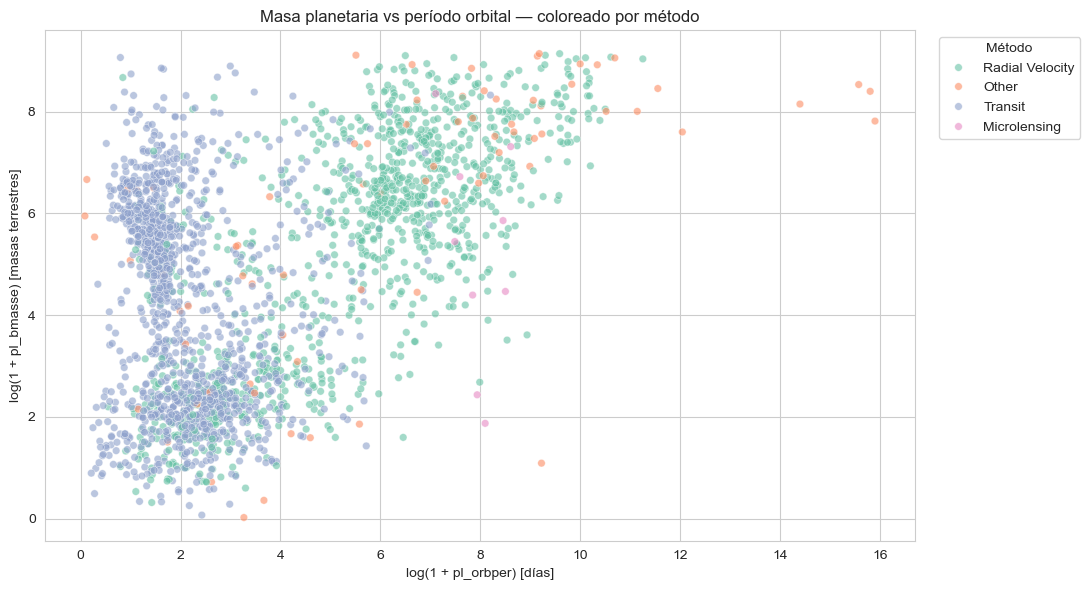

In [8]:
df_both_real = df[(df["pl_bmasse_missing"] == 0) & (df["pl_orbper_missing"] == 0)].copy()
print(f"Planetas con masa y período medidos simultáneamente: {len(df_both_real)}")

plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_both_real, x="pl_orbper_log", y="pl_bmasse_log",
                hue="discoverymethod", palette="Set2", alpha=0.6, s=30)
plt.title("Masa planetaria vs período orbital — coloreado por método")
plt.xlabel("log(1 + pl_orbper) [días]")
plt.ylabel("log(1 + pl_bmasse) [masas terrestres]")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Método")
plt.tight_layout()
plt.show()

**Interpretación H2:** se observa que Radial Velocity tiende a poblar el cuadrante superior del gráfico (planetas masivos), mientras que Transit cubre un rango más amplio de masas, dominando especialmente los planetas de menor masa con períodos cortos. Esto es consistente con los sesgos físicos de cada método. Los tests de Kruskal-Wallis confirman estadísticamente que **tanto la masa como el período orbital difieren significativamente** entre métodos.

## 7. Validación H3 — Sesgo de distancia al sistema

Planetas con distancia medida: 5636


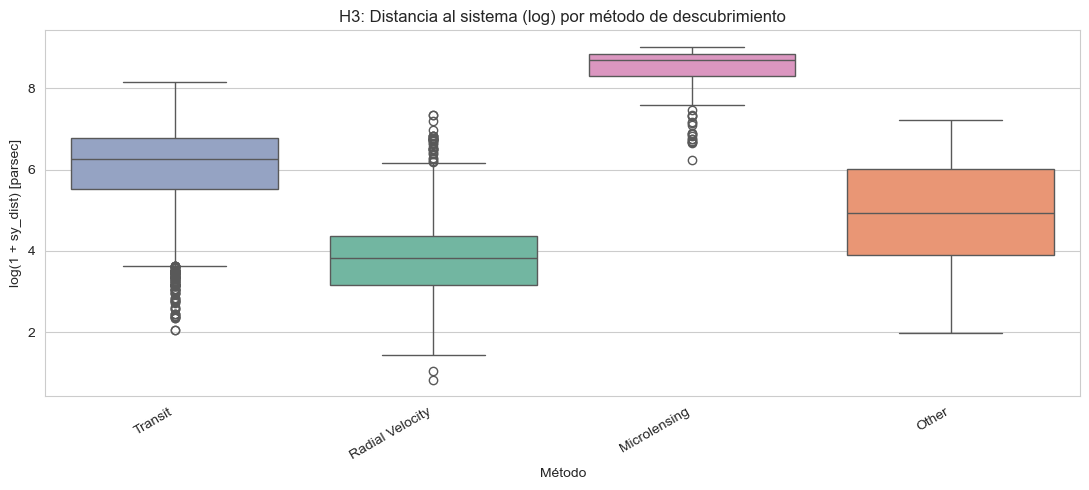


Mediana de sy_dist (parsec) por método:
discoverymethod
Microlensing      6015.0000
Transit            521.8000
Other              138.5000
Radial Velocity     44.4000
Name: sy_dist, dtype: float64

Kruskal-Wallis: H = 2357.95, p-value = 0.0000e+00
Conclusión: Rechazamos H0 (las distancias difieren entre métodos) (α = 0.05)


In [9]:
df_dist_real = df[df["sy_dist_missing"] == 0].copy()
print(f"Planetas con distancia medida: {len(df_dist_real)}")

order_dist = df_dist_real["discoverymethod"].value_counts().index

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_dist_real, x="discoverymethod", y="sy_dist_log",
            order=order_dist, hue="discoverymethod", palette="Set2", legend=False)
plt.title("H3: Distancia al sistema (log) por método de descubrimiento")
plt.ylabel("log(1 + sy_dist) [parsec]")
plt.xlabel("Método")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nMediana de sy_dist (parsec) por método:")
print(df_dist_real.groupby("discoverymethod")["sy_dist"].median().sort_values(ascending=False).round(1))

grupos_dist = [g["sy_dist_log"].dropna().values for _, g in df_dist_real.groupby("discoverymethod") if len(g) > 5]
stat_d, p_d = stats.kruskal(*grupos_dist)
print(f"\nKruskal-Wallis: H = {stat_d:.2f}, p-value = {p_d:.4e}")
print("Conclusión:", "Rechazamos H0 (las distancias difieren entre métodos)" if p_d < 0.05
      else "No rechazamos H0", "(α = 0.05)")

**Interpretación H3:** se confirma que la mediana de distancia varía sensiblemente entre métodos. Microlensing tiende a detectar sistemas a **mucha mayor distancia** que Transit o Radial Velocity, lo cual es coherente con la naturaleza física de cada técnica (Microlensing puede operar a kiloparsecs porque depende del efecto gravitacional lente, no de medir luz directa del planeta).

## 8. Hipótesis adicional H4 — Relación masa-radio

Aprovechamos las observaciones reales (no imputadas) para mirar la relación masa-radio, que es una **ley empírica conocida** en astronomía. Esperamos ver una correlación positiva fuerte, posiblemente con quiebres asociados a las distintas familias planetarias (rocosos, neptunianos, gigantes gaseosos).

Planetas con masa y radio medidos simultáneamente: 1306


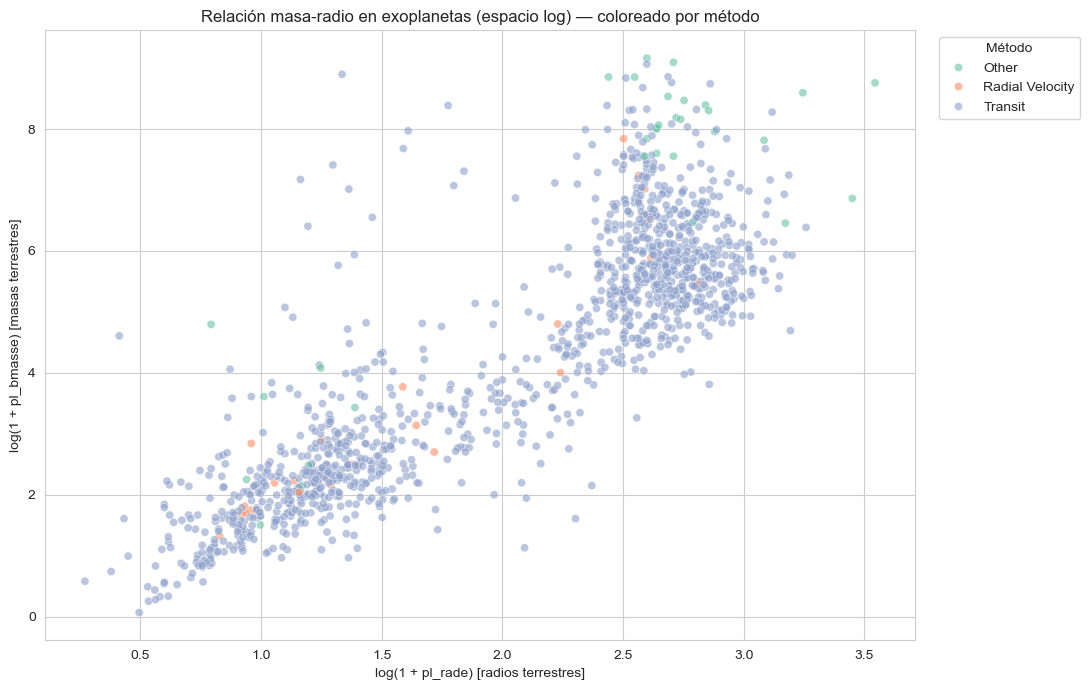


Correlación de Spearman entre radio y masa: rho = 0.822, p-value = 1.5168e-320
Conclusión: Existe relación monótona significativa (rho = 0.82)


In [10]:
df_real = df[(df["pl_rade_missing"] == 0) & (df["pl_bmasse_missing"] == 0)].copy()
print(f"Planetas con masa y radio medidos simultáneamente: {len(df_real)}")

plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_real, x="pl_rade_log", y="pl_bmasse_log",
                hue="discoverymethod", palette="Set2", alpha=0.6, s=35)
plt.title("Relación masa-radio en exoplanetas (espacio log) — coloreado por método")
plt.xlabel("log(1 + pl_rade) [radios terrestres]")
plt.ylabel("log(1 + pl_bmasse) [masas terrestres]")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Método")
plt.tight_layout()
plt.show()

rho, p_rho = stats.spearmanr(df_real["pl_rade_log"], df_real["pl_bmasse_log"])
print(f"\nCorrelación de Spearman entre radio y masa: rho = {rho:.3f}, p-value = {p_rho:.4e}")
print("Conclusión:", "Existe relación monótona significativa" if p_rho < 0.05 else "No hay evidencia de relación",
      f"(rho = {rho:.2f})")

**Interpretación H4:** la correlación de Spearman positiva y significativa confirma la relación monótona masa-radio. El gráfico muestra además que **los distintos métodos pueblan zonas diferentes del plano masa-radio**, reforzando que las variables físicas son útiles para discriminar el método de descubrimiento.

## 9. Variables estelares vs método

Como análisis complementario revisamos si las propiedades de la **estrella anfitriona** (temperatura, masa, metalicidad) también se distribuyen distinto según el método. La metalicidad estelar (`st_met`) es históricamente conocida por correlacionar con la presencia de planetas gigantes.

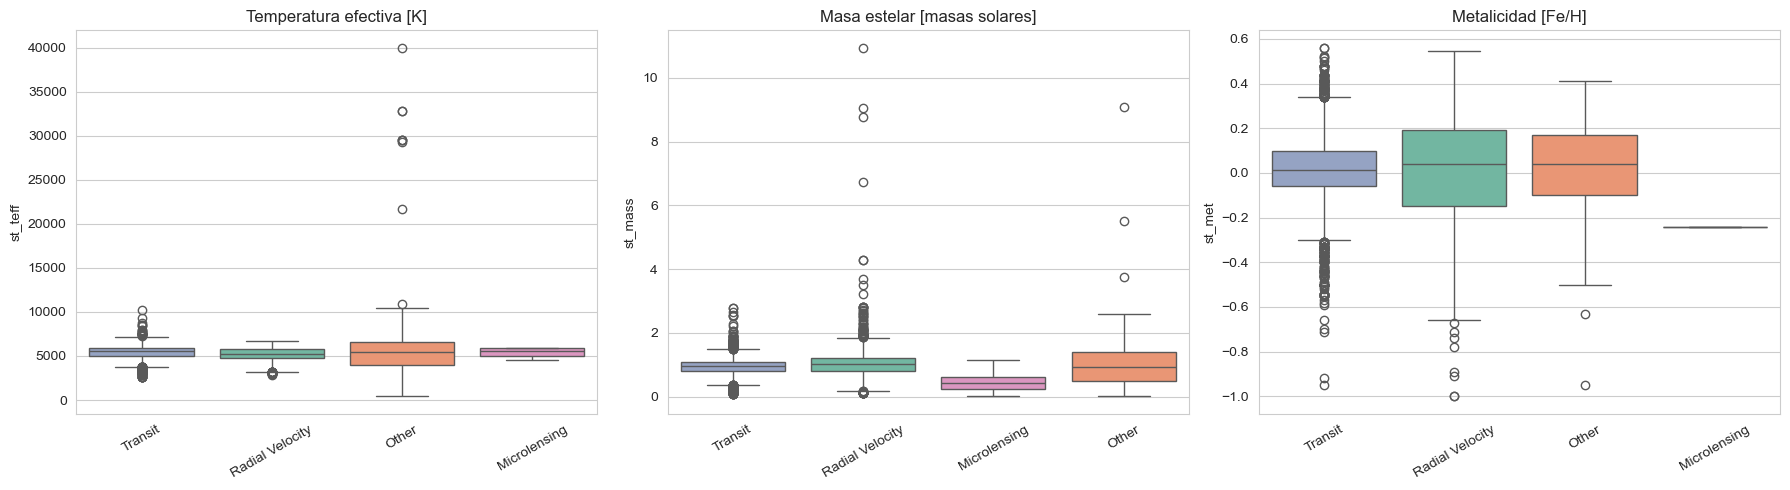

Mediana de variables estelares por método:
                  st_teff  st_mass  st_met
discoverymethod                           
Microlensing    5551.0000   0.4300  0.0200
Other           5551.0000   0.9500  0.0200
Radial Velocity 5551.0000   1.0200  0.0200
Transit         5580.0000   0.9500  0.0200


In [11]:
stellar_vars = [("st_teff", "Temperatura efectiva [K]"),
                ("st_mass", "Masa estelar [masas solares]"),
                ("st_met", "Metalicidad [Fe/H]")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (var, label) in zip(axes, stellar_vars):
    missing_col = f"{var}_missing"
    subset = df[df[missing_col] == 0] if missing_col in df.columns else df
    order_s = subset["discoverymethod"].value_counts().index
    sns.boxplot(data=subset, x="discoverymethod", y=var, order=order_s,
                hue="discoverymethod", palette="Set2", legend=False, ax=ax)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

print("Mediana de variables estelares por método:")
print(df.groupby("discoverymethod")[["st_teff", "st_mass", "st_met"]].median().round(3))

## 10. Conclusiones del EDA

### Hallazgos por hipótesis

| Hipótesis | Resultado | Implicación para el modelo |
|---|---|---|
| **H1 — Radio planetario** | Validada: distribuciones significativamente distintas entre métodos (Kruskal-Wallis p < 0.05) | `pl_rade_log` será una **feature fuerte** |
| **H2 — Masa y período** | Validada: Radial Velocity favorece planetas masivos; Transit cubre rango más amplio | `pl_bmasse_log` y `pl_orbper_log` aportan poder discriminante |
| **H3 — Distancia** | Validada: Microlensing detecta sistemas mucho más lejanos | `sy_dist_log` es discriminante, especialmente para separar Microlensing del resto |
| **H4 — Masa-radio** | Validada: correlación de Spearman positiva y significativa | Relación física conocida; útil para chequear coherencia de datos |

### Observaciones generales

- **Fuerte desbalance de clases:** Transit domina ampliamente. Es necesario usar métricas robustas al desbalance (F1 macro, balanced accuracy) y considerar técnicas como `class_weight="balanced"` o SMOTE durante el modelado.
- **Asimetría de variables:** las versiones logarítmicas creadas en el ETL (`*_log`) son más informativas que las originales para análisis estadístico y probablemente para modelos lineales. Modelos basados en árboles son menos sensibles, pero igual conviene tener ambas versiones disponibles.
- **Imputación con mediana:** dado el alto porcentaje de nulos en algunas variables (`pl_bmasse` ~53%, `pl_orbeccen` ~59%), los indicadores `_missing` que generamos son **variables informativas en sí mismas**: capturan el sesgo de qué método mide qué variable.
- **Multicolinealidad:** la matriz de correlación muestra que `st_mass`, `st_rad` y `st_teff` están fuertemente correlacionadas entre sí (esperable físicamente). Lo mismo entre las magnitudes ópticas (`sy_vmag`, `sy_kmag`, `sy_gaiamag`). Esto deberá considerarse al elegir el modelo.

### Próximos pasos (Sprint 3)

1. **Codificar el target** con `LabelEncoder` o `OneHotEncoder` según el modelo.
2. **Separar train/test** con `stratify=discoverymethod` por el desbalance.
3. **Probar modelos baseline:** Regresión Logística multiclase (con escalado), Random Forest, Gradient Boosting (XGBoost/LightGBM).
4. **Métricas:** matriz de confusión, F1 macro, accuracy balanceado.
5. **Importancia de features:** validar que las variables identificadas en este EDA (radio, masa, período, distancia) aparezcan entre las top según el modelo.